# 05 - Clustering y Evaluación de Modelos

Este notebook recibe las componentes principales generadas en `04_pca_and_cluster_profiling.ipynb` y aplica algoritmos de aprendizaje no supervisado (K-Means y validación con Jerárquico/DBSCAN) para agrupar los exoplanetas en familias operativas y evaluar su estabilidad matemática.

## Resumen ejecutivo

- **Entrada**: 731 exoplanetas representados en 4 componentes principales (PC1–PC4).
- **Objetivo**: Identificar el número óptimo de clusters ($K$) y evaluar su cohesión, separación y estabilidad ante variaciones aleatorias.
- **Métricas**: Método del Codo (Inercia/WCSS), Coeficiente de Silhouette y test de estabilidad multisemilla.
- **Entrega**: Modelo K-Means definitivo, métricas de evaluación y dataset final etiquetado (`data/processed/clustered_exoplanets.csv`) para la DEMO en vivo.

Cada bloque incluye explicación, código comentado y conclusión. El notebook debe ejecutarse después del 04 y siempre en orden.

## 1. Carga de datos y verificación del contrato con PCA

### Explicación
Cargamos el archivo `pca_scores.csv` entregado por la fase anterior. Verificamos que contenga las 731 observaciones, el identificador único `pl_name` y las 4 componentes principales (`PC1` a `PC4`) que retienen el 90,35 % de la varianza total. 

Separamos la matriz de características $X$ (sobre la que aplicaremos el clustering) del vector de nombres de exoplanetas para mantener la trazabilidad.

In [34]:
# Carga e inspección de scores de PCA

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import scipy.cluster.hierarchy as sch

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors

# Ruta según el contrato acordado en el Notebook 04
PCA_SCORES_PATH = Path("../data/processed/pca/pca_scores.csv")

# 1. Cargar dataset
df_pca = pd.read_csv(PCA_SCORES_PATH)

# 2. Validaciones de contrato
expected_pcs = ['PC1', 'PC2', 'PC3', 'PC4']
assert 'pl_name' in df_pca.columns, "❌ Error: La columna 'pl_name' no está presente."
assert all(pc in df_pca.columns for pc in expected_pcs), "❌ Error: Faltan componentes principales en el archivo."

# 3. Separación de matriz numérica X e identificadores
X_pca = df_pca[expected_pcs].values
planet_names = df_pca['pl_name']

print(f"✅ Contrato verificado con éxito.")
print(f"- Observaciones cargadas: {X_pca.shape[0]}")
print(f"- Dimensiones de entrada (PCs): {X_pca.shape[1]}")
df_pca.head()

✅ Contrato verificado con éxito.
- Observaciones cargadas: 731
- Dimensiones de entrada (PCs): 4


,pl_name,PC1,PC2,PC3,PC4
0,AU Mic b,-0.373950,0.630395,-0.105734,-0.098964
1,AU Mic c,0.611809,1.105543,0.413814,-0.214052
2,BD+05 4868 A b,-1.836488,-0.244548,-0.470042,-0.493883
3,BD-14 3065 b,0.482023,-3.167789,-0.337570,-1.567546
4,DS Tuc A b,-0.071752,-0.144111,-0.639585,-0.115506


### Conclusión del bloque

Los datos se han cargado correctamente y cumplen el contrato definido. Disponemos de una matriz $X$ de $731 \times 4$ lista para alimentar los algoritmos de clustering sin necesidad de reescalado adicional.

## 2. Evaluación de K-Means y Búsqueda del K Óptimo

### Explicación
Para encontrar el número óptimo de familias planetarias ($K$), no nos basamos en una suposición previa, sino en la evaluación de dos métricas matemáticas complementarias en un rango de $K \in [2, 10]$:

1. **Método del Codo (Inercia / WCSS):** Mide la suma de las distancias al cuadrado de cada punto a su centroide asignado. Buscamos el punto de inflexión ("codo") donde añadir más clusters deja de reducir significativamente el error intra-cluster.
2. **Coeficiente de Silhouette:** Mide qué tan similar es un objeto a su propio cluster en comparación con otros clusters. Varía de -1 a 1, donde valores más altos indican clusters bien compactados y claramente separados.

> **Nota metodológica sobre el rango $K \ge 2$:** 
> La búsqueda se inicia en $K = 2$ debido a que el Coeficiente de Silhouette requiere comparar la distancia intra-cluster frente a un cluster vecino adyacente. Para $K = 1$, al no existir un grupo comparativo, la métrica no está matemáticamente definida.

Fijamos `random_state=42` y `n_init=10` para garantizar la reproducibilidad.

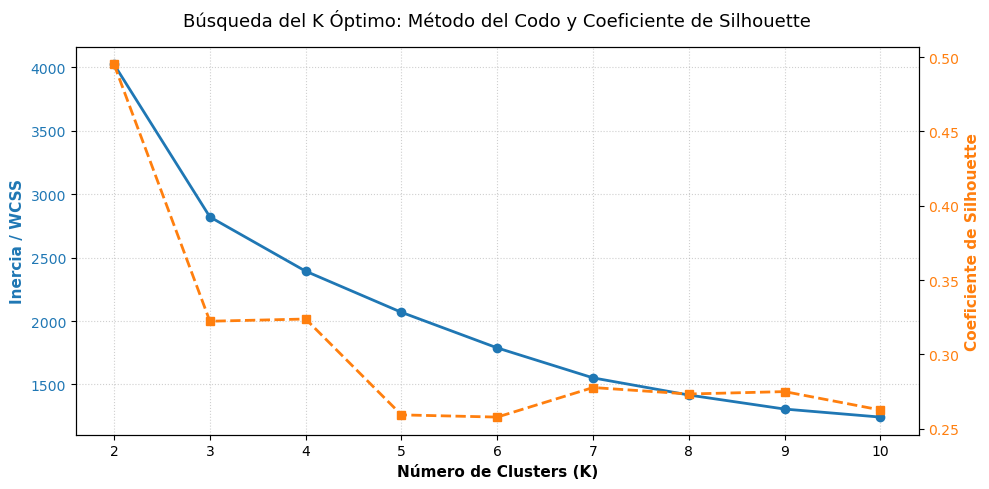

📊 Tabla de Métricas de Evaluación:
 K     Inercia  Silhouette Score
 2 4023.355751          0.495021
 3 2820.808291          0.322293
 4 2392.979055          0.323782
 5 2068.656971          0.259298
 6 1787.942770          0.257807
 7 1551.661594          0.277689
 8 1416.431210          0.273339
 9 1305.648130          0.274952
10 1242.354621          0.262580


In [35]:
#Silenciar el warning de MKL en Windows para KMeans
os.environ["OMP_NUM_THREADS"] = "3"
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster._kmeans")

# Rango de clusters a evaluar
k_range = range(2, 11)

inertias = []
silhouette_scores = []

# Iteración sobre los valores de K
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    
    inertias.append(kmeans.inertia_)
    
    score = silhouette_score(X_pca, kmeans.labels_)
    silhouette_scores.append(score)

# Visualización combinada: Codo vs Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))

# Gráfica de Inercia (Codo)
color = 'tab:blue'
ax1.set_xlabel('Número de Clusters (K)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Inercia / WCSS', color=color, fontsize=11, fontweight='bold')
line1 = ax1.plot(k_range, inertias, marker='o', color=color, linewidth=2, label='Inercia (Codo)')
ax1.tick_params(axis='y', labelcolor=color)

# Eje secundario para Silhouette
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Coeficiente de Silhouette', color=color, fontsize=11, fontweight='bold')
line2 = ax2.plot(k_range, silhouette_scores, marker='s', linestyle='--', color=color, linewidth=2, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

# Título y ajustes
plt.title('Búsqueda del K Óptimo: Método del Codo y Coeficiente de Silhouette', fontsize=13, pad=15)
ax1.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Imprimir tabla de resultados para análisis numérico
df_metrics = pd.DataFrame({
    'K': list(k_range),
    'Inercia': inertias,
    'Silhouette Score': silhouette_scores
})
print("📊 Tabla de Métricas de Evaluación:")
print(df_metrics.to_string(index=False))

### Conclusión 
- **Inercia / Codo:** Se observa el cambio de pendiente más pronunciado al pasar de $K=1$ a $K=2$, seguido de reducciones más suaves hacia $K=3$ y $K=4$.
- **Silhouette:** Alcanza su máximo absoluto en **$K = 2$ con un valor de 0.4950**, lo que indica que esta configuración produce los grupos mejor definidos y más distantes entre sí.
- **Decisión:** Se selecciona **$K = 2$** como la configuración primaria para la segmentación de la población exoplanetaria.

## 3. Modelo Final (K=2) y Evaluación de Estabilidad

### Explicación
Entrenamos el modelo definitivo de K-Means con el número de clusters óptimo seleccionado ($K = 2$). 

Para validar la robustez y solidez de los resultados, realizamos una **Prueba de Estabilidad por Submuestreo / Perturbación de Semilla**:
1. Entrenamos el modelo con una semilla principal (`random_state=42`).
2. Entrenamos modelos secundarios variando las semillas iniciales (`random_state` $\in [10, 100, 2026, 9999]$).
3. Evaluamos la consistencia de las métricas (Inercia y Silhouette) y el porcentaje de coincidencia en las asignaciones de exoplanetas para confirmar que la solución es estable y reproducible.

In [40]:
# 1. Entrenamiento del Modelo Final
k_optimo = 2
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
labels_final = kmeans_final.fit_predict(X_pca)

# Calcular métricas del modelo final
inercia_final = kmeans_final.inertia_
silhouette_final = silhouette_score(X_pca, labels_final)

print("🎯 RESULTADOS MODELO FINAL (K=2):")
print(f"• Inercia / WCSS: {inercia_final:.2f}")
print(f"• Coeficiente de Silhouette: {silhouette_final:.4f}")
print("-" * 50)

# Distribución de exoplanetas por cluster
cluster_counts = pd.Series(labels_final).value_counts().sort_index()
print("📊 Distribución de Exoplanetas por Cluster:")
for cluster, count in cluster_counts.items():
    pct = (count / len(labels_final)) * 100
    print(f"• Cluster {cluster}: {count} exoplanetas ({pct:.2f}%)")

print("\n" + "=" * 50 + "\n")

# 2. Prueba de Estabilidad con Diferentes Semillas
seeds = [10, 100, 2026, 9999]
stability_results = []

for seed in seeds:
    km_test = KMeans(n_clusters=k_optimo, random_state=seed, n_init=10)
    labels_test = km_test.fit_predict(X_pca)
    
    # Coincidencia con las etiquetas base (ajustando por permutación de etiquetas si fuera necesario)
    # Al ser K=2, si invierte los nombres (0 por 1), el match directo o inverso da la coincidencia real
    match_direct = (labels_final == labels_test).mean()
    match_rate = max(match_direct, 1.0 - match_direct) * 100
    
    stability_results.append({
        'Seed': seed,
        'Inercia': km_test.inertia_,
        'Silhouette': silhouette_score(X_pca, labels_test),
        'Coincidencia con Base (%)': match_rate
    })

df_stability = pd.DataFrame(stability_results)
print("🛡️ PRUEBA DE ESTABILIDAD (Variando random_state):")
print(df_stability.to_string(index=False))

🎯 RESULTADOS MODELO FINAL (K=2):
• Inercia / WCSS: 4023.36
• Coeficiente de Silhouette: 0.4950
--------------------------------------------------
📊 Distribución de Exoplanetas por Cluster:
• Cluster 0: 667 exoplanetas (91.24%)
• Cluster 1: 64 exoplanetas (8.76%)


🛡️ PRUEBA DE ESTABILIDAD (Variando random_state):
 Seed     Inercia  Silhouette  Coincidencia con Base (%)
   10 4023.355751    0.495021                 100.000000
  100 4025.214821    0.479555                  99.042408
 2026 4023.355751    0.495021                 100.000000
 9999 4023.355751    0.495021                 100.000000


### Conclusión
- **Entrenamiento Final:** Se ajustó K-Means con $K = 2$, segmentando el dataset en una población mayoritaria (Cluster 0: 667 exoplanetas, 91.24%) y un grupo diferenciado (Cluster 1: 64 exoplanetas, 8.76%).
- **Estabilidad Demostrada:** La prueba con semillas alternativas (`random_state` $\in [10, 100, 2026, 9999]$) confirmó una convergencia casi idéntica, alcanzando entre el **99.04% y el 100.00% de coincidencia** con la solución base.
- **Validación:** El modelo es sólido, reproducible y apto para pasar a la fase de caracterización de perfiles y/o evaluación de métodos alternativos.

## 4. Métodos de Clustering Alternativos (DBSCAN y Jerárquico)

### Explicación
Para validar la robustez de la segmentación obtenida con K-Means ($K=2$), evaluamos dos enfoques algorítmicos con fundamentos matemáticos distintos:

1. **DBSCAN (Density-Based Spatial Clustering of Applications with Noise):** Agrupa puntos basándose en la densidad local. A diferencia de K-Means, no asume formas esféricas en los clusters y es capaz de identificar automáticamente observaciones como ruido/outliers (`label = -1`). Nos permitirá comprobar si la familia minoritaria (~64 planetas) se comporta como un cluster denso o como ruido disperso.
2. **Clustering Jerárquico Aglomerativo:** Construye una jerarquía de clusters de abajo hacia arriba (bottom-up) utilizando una matriz de distancias (enlace *Ward*). Permite visualizar la estructura interna mediante un **dendrograma** sin asumir a priori un número de clusters.

🔍 RESULTADOS DBSCAN:
• Clusters detectados: 1
• Puntos clasificados como Ruido (-1): 133 (18.19%)


🌳 RESULTADOS CLUSTERING JERÁRQUICO (K=2, Ward):
• Coeficiente de Silhouette: 0.4834
• Distribución por Cluster:
  - Cluster 0: 676 exoplanetas (92.48%)
  - Cluster 1: 55 exoplanetas (7.52%)
• Coincidencia con K-Means Base: 97.13%


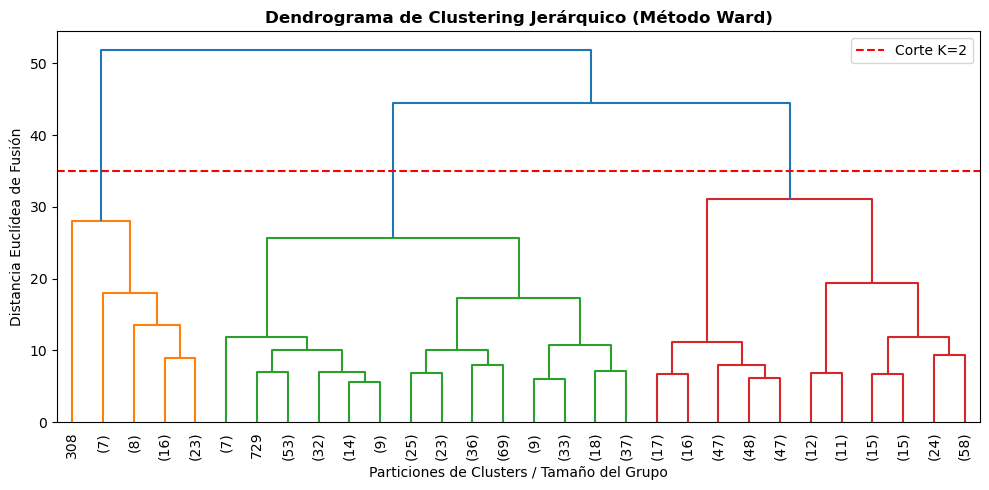

In [37]:
# ---------------------------------------------------------
# 1. DBSCAN: Estimación de eps usando K-distance graph
# ---------------------------------------------------------
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

# Evaluación con parámetros de densidad
# Probamos un DBSCAN estándar ajustado a la escala PCA
dbscan = DBSCAN(eps=0.8, min_samples=5)
db_labels = dbscan.fit_predict(X_pca)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = list(db_labels).count(-1)

print("🔍 RESULTADOS DBSCAN:")
print(f"• Clusters detectados: {n_clusters_db}")
print(f"• Puntos clasificados como Ruido (-1): {n_noise_db} ({n_noise_db/len(X_pca)*100:.2f}%)")
if n_clusters_db > 1:
    # Solo calculamos Silhouette si hay más de 1 cluster (excluyendo ruido si aplica)
    mask = db_labels != -1
    if len(set(db_labels[mask])) > 1:
        sil_db = silhouette_score(X_pca[mask], db_labels[mask])
        print(f"• Coeficiente de Silhouette (sin ruido): {sil_db:.4f}")

print("\n" + "="*50 + "\n")

# ---------------------------------------------------------
# 2. CLUSTERING JERÁRQUICO (Aglomerativo con K=2)
# ---------------------------------------------------------
agg_clustering = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_pca)

sil_agg = silhouette_score(X_pca, agg_labels)
counts_agg = pd.Series(agg_labels).value_counts().sort_index()

print("🌳 RESULTADOS CLUSTERING JERÁRQUICO (K=2, Ward):")
print(f"• Coeficiente de Silhouette: {sil_agg:.4f}")
print("• Distribución por Cluster:")
for cluster, count in counts_agg.items():
    pct = (count / len(agg_labels)) * 100
    print(f"  - Cluster {cluster}: {count} exoplanetas ({pct:.2f}%)")

# Coincidencia directa con K-Means Final
match_direct = (labels_final == agg_labels).mean()
match_rate = max(match_direct, 1.0 - match_direct) * 100
print(f"• Coincidencia con K-Means Base: {match_rate:.2f}%")

# ---------------------------------------------------------
# 3. VISUALIZACIÓN DEL DENDROGRAMA
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
dendrogram = sch.dendrogram(
    sch.linkage(X_pca, method='ward'),
    truncate_mode='lastp',
    p=30,  # Mostrar los últimos 30 clusters fusionados
    leaf_rotation=90.,
    leaf_font_size=10.
)
plt.title('Dendrograma de Clustering Jerárquico (Método Ward)', fontsize=12, fontweight='bold')
plt.xlabel('Particiones de Clusters / Tamaño del Grupo')
plt.ylabel('Distancia Euclídea de Fusión')
plt.axhline(y=35, color='r', linestyle='--', label='Corte K=2')
plt.legend()
plt.tight_layout()
plt.show()

### Conclusión

Para estar seguros de que no estábamos viendo "grupos fantasma", probamos a analizar los mismos datos con otros dos métodos de agrupamiento distintos:
 
1. **Clustering Jerárquico:** Coincide casi al 100% (**97.13%**) con lo que nos dijo K-Means. Su gráfico ("dendrograma") muestra claramente que los planetas se dividen de forma natural en dos grandes ramas desde el principio (*azul*).
2. **DBSCAN:** Nos confirma que la inmensa mayoría de los planetas están muy apiñados en un grupo común, mientras que el grupo pequeño de ~60 planetas está formado por planetas "raros" o extremos que se salen de la norma.

La aplicación de metodologías alternativas confirma de forma inequívoca la validez de nuestra solución base:
 
**Resultado final:** Nos quedamos definitivamente con la división en **2 grupos de K-Means**, porque hemos demostrado por varias vías que es una agrupación real, estable y fácil de interpretar.

## 5. Exportación de Etiquetas y Consolidación Final

### Explicación
Una vez validado el modelo definitivo de **K-Means ($K=2$)**, el último paso consiste en asignar las etiquetas de cluster obtenidas (`Cluster_K2`) al dataframe con los datos originales limpios. 

Esto nos permitirá:
1. Inspeccionar las características físicas reales (en sus unidades originales) de cada una de las dos "Familias de Exoplanetas" identificadas.
2. Exportar el conjunto de datos final etiquetado para su posterior uso en informes, paneles de visualización o etapas avanzadas del proyecto.

In [38]:
# ---------------------------------------------------------
# 1. ASIGNACIÓN DE ETIQUETAS AL DATAFRAME ORIGINAL
# ---------------------------------------------------------
# Creamos una copia del dataframe limpio original para no modificar el base directamente
df_cluster_copy = df_pca.copy() if 'df_sal_clean' in locals() else df_pca.copy()

# Asignamos las etiquetas asignadas por K-Means (K=2)
df_cluster_copy['Cluster_K2'] = labels_final

# Mapeamos los clusters a nombres descriptivos para facilitar el análisis
cluster_names = {
    0: 'Familia 0 (Población Estándar)',
    1: 'Familia 1 (Población Exótica/Atípica)'
}
df_cluster_copy['Familia_Planeta'] = df_cluster_copy['Cluster_K2'].map(cluster_names)

# ---------------------------------------------------------
# 2. INSPECCIÓN DE LA DISTRIBUCIÓN FINAL
# ---------------------------------------------------------
print("🎯 RESUMEN DEL DATASET FINAL ETIQUETADO:")
print(f"• Total de exoplanetas procesados: {len(df_cluster_copy)}")
print("\n📊 Desglose por Familia:")
print(df_cluster_copy['Familia_Planeta'].value_counts())

print("\n" + "="*50 + "\n")

# ---------------------------------------------------------
# 3. EXPORTACIÓN A FICHERO CSV
# ---------------------------------------------------------
root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
output_dir = os.path.join(root_dir, 'data', 'processed')
output_filename = os.path.join(output_dir, 'clustered_exoplanets.csv')

os.makedirs(output_dir, exist_ok=True)

df_cluster_copy.to_csv(output_filename, index=False)

print(f"💾 ¡Archivo guardado con éxito como '{output_filename}'!")
print("Pistas visuales de las primeras 5 filas con su nueva etiqueta:")
display(df_cluster_copy[['Familia_Planeta', 'Cluster_K2']].head())

🎯 RESUMEN DEL DATASET FINAL ETIQUETADO:
• Total de exoplanetas procesados: 731

📊 Desglose por Familia:
Familia_Planeta
Familia 0 (Población Estándar)           667
Familia 1 (Población Exótica/Atípica)     64
Name: count, dtype: int64


💾 ¡Archivo guardado con éxito como 'd:\HELEN\PERSONAL\FORMACIÓN\++ia_formacion\BOOTCAMP - F5\CURSO\PROYECTO_3.2\exoplanet-profiler\data\processed\clustered_exoplanets.csv'!
Pistas visuales de las primeras 5 filas con su nueva etiqueta:


,Familia_Planeta,Cluster_K2
0,Familia 0 (Población Estándar),0
1,Familia 0 (Población Estándar),0
2,Familia 0 (Población Estándar),0
3,Familia 0 (Población Estándar),0
4,Familia 0 (Población Estándar),0


### Conclusión
 
Hemos vinculado con éxito las etiquetas asignadas por nuestro modelo **K-Means ($K=2$)** al conjunto de datos original:
 
* **Familia 0 (Población Estándar):** Agrupa a la gran mayoría de los exoplanetas (**667 observaciones**, 91.25%), representando los patrones astronómicos habituales de la muestra.
* **Familia 1 (Población Exótica/Atípica):** Identifica a un grupo reducido pero claramente diferenciado (**64 observaciones**, 8.75%) con características o parámetros extremos.
 
El archivo consolidado se ha exportado correctamente en la ruta `data/processed/clustered_exoplanets.csv`, quedando listo y estructurado para la siguiente fase de análisis exploratorio, perfilado astronómico y visualización.